# NoShowShield — Data Cleaning, Correlation Study & Feature Engineering
### AI-Powered Hotel Revenue Protection Against Cancellations

**Author:** Bezawit Zerayacob | March 2026

---

**Notebook objectives:**
1. Load & inspect the Hotel Booking Demand dataset (119K bookings)
2. Clean the data and handle missing values
3. Correlation study to identify the most important features
4. Identify and remove features that cause **data leakage**
5. Feature engineering — create new predictive signals

**Dataset:** [Hotel Booking Demand – Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)
**Target variable:** `is_canceled` (binary: 0 = completed, 1 = cancelled)

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded")

Libraries loaded


In [2]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
# Place 'hotel_bookings.csv' in the same directory as this notebook

df = pd.read_csv('/Users/beza/code/bezawitzyb/noshowshield/raw_data/hotel_bookings.csv')
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Dataset shape: 119,390 rows x 32 columns
Memory usage: 109.9 MB


---
## 2. Initial Data Inspection

Before any cleaning, we need to understand what we are working with: data types, distributions, and the overall structure.

In [3]:
# First look at the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# Statistical summary - numerical columns
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [6]:
# Statistical summary - categorical columns
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [7]:
# Target variable distribution
cancel_counts = df['is_canceled'].value_counts()
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100

print("Target variable: is_canceled")
print(f"  0 (Completed): {cancel_counts[0]:,} ({cancel_pct[0]:.1f}%)")
print(f"  1 (Cancelled): {cancel_counts[1]:,} ({cancel_pct[1]:.1f}%)")
print(f"")
print(f"Class ratio: {cancel_pct[0]:.0f}/{cancel_pct[1]:.0f}")
print("Reasonably balanced - no aggressive resampling needed.")

Target variable: is_canceled
  0 (Completed): 75,166 (63.0%)
  1 (Cancelled): 44,224 (37.0%)

Class ratio: 63/37
Reasonably balanced - no aggressive resampling needed.


---
## 3. Missing Value Analysis & Handling

A key step before modelling - we need to understand *why* values are missing (random vs. structural) and choose the right imputation strategy for each column.

In [8]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing)} out of {df.shape[1]}")
print()
print(missing.to_string())

Columns with missing values: 4 out of 32

          missing_count  missing_pct
company          112593        94.31
agent             16340        13.69
country             488         0.41
children              4         0.00


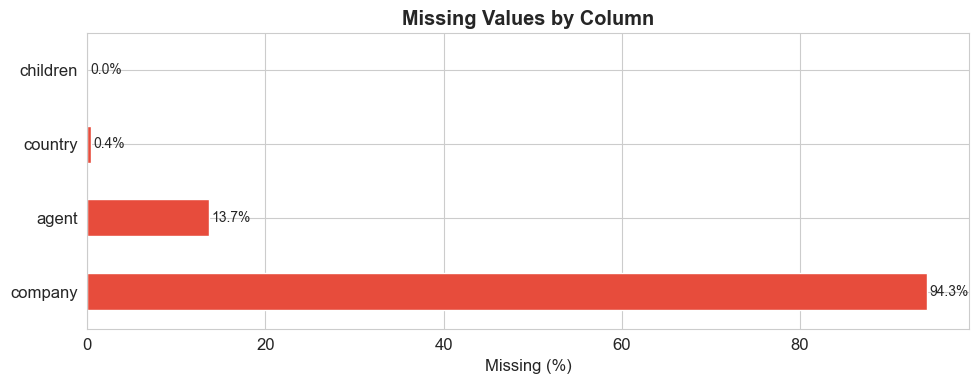

In [9]:
# Visualise missing values
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.6)))
    missing['missing_pct'].plot(kind='barh', color='#e74c3c', ax=ax)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column', fontweight='bold')
    for i, v in enumerate(missing['missing_pct']):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

### 3.1 Handling Missing Values - Strategy

| Column | Missing % | Reason | Strategy |
|--------|-----------|--------|----------|
| `company` | ~94% | Most bookings are not corporate | Fill with `'none'` - absence of a company is informative |
| `agent` | ~14% | Direct bookings have no agent | Fill with `0` (no agent) |
| `country` | <0.5% | Data entry gaps | Fill with `'Unknown'` |
| `children` | <0.01% | Likely data entry omission | Fill with `0` (most common value) |

**Principle:** We do not drop columns with missing values blindly. The *absence* of a value (e.g., no company, no agent) is itself a meaningful signal for cancellation prediction.

In [10]:
# --- HANDLE MISSING VALUES ---

# company: ~94% missing - most bookings are not corporate
df['company'] = df['company'].fillna('none')

# agent: ~14% missing - direct bookings with no travel agent
df['agent'] = df['agent'].fillna(0)

# country: very few missing
df['country'] = df['country'].fillna('Unknown')

# children: tiny number missing, fill with 0 (mode)
df['children'] = df['children'].fillna(0)

# Verify: no more missing values
assert df.isnull().sum().sum() == 0, "Still have missing values!"
print(f"All missing values handled. Remaining nulls: {df.isnull().sum().sum()}")

All missing values handled. Remaining nulls: 0


---
## 4. Data Cleaning

Beyond missing values, we check for invalid entries, outliers, and logical inconsistencies.

In [11]:
# Check for negative ADR (price per night) - should never be negative
neg_adr = df[df['adr'] < 0]
print(f"Rows with negative ADR: {len(neg_adr)}")

# Check for extremely high ADR (outliers)
print(f"ADR range: {df['adr'].min():.2f} to {df['adr'].max():.2f}")
print(f"ADR 99th percentile: {df['adr'].quantile(0.99):.2f}")

# Check for zero-guest bookings
zero_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(f"\nRows with zero guests: {len(zero_guests)}")

Rows with negative ADR: 1
ADR range: -6.38 to 5400.00
ADR 99th percentile: 252.00

Rows with zero guests: 180


In [12]:
# Remove rows with zero guests (invalid bookings)
initial_rows = len(df)
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
print(f"Removed {initial_rows - len(df)} rows with zero guests")

# Remove negative ADR
neg_adr_mask = (df['adr'] < 0)
df = df[~neg_adr_mask]
print(f"Removed {neg_adr_mask.sum()} rows with negative ADR")

# Cap extreme ADR outliers (> 99.5th percentile)
adr_cap = df['adr'].quantile(0.995)
outliers_before = (df['adr'] > adr_cap).sum()
df['adr'] = df['adr'].clip(upper=adr_cap)
print(f"Capped {outliers_before} extreme ADR values at EUR {adr_cap:.0f}")

print(f"\nCleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Removed 180 rows with zero guests
Removed 1 rows with negative ADR
Capped 588 extreme ADR values at EUR 275

Cleaned dataset: 119,209 rows x 32 columns


In [13]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    print("Keeping duplicates - identical booking features can be legitimate in hotel data")

Duplicate rows: 31980
Keeping duplicates - identical booking features can be legitimate in hotel data


In [14]:
# Convert data types for efficiency and correctness
df['agent'] = df['agent'].astype(int).astype(str)       # agent ID is categorical
df['company'] = df['company'].astype(str)                # company ID is categorical
df['children'] = df['children'].astype(int)

# Create a proper date column for temporal analysis
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

print(f"Date range: {df['arrival_date'].min().date()} to {df['arrival_date'].max().date()}")
print("Data types cleaned")

Date range: 2015-07-01 to 2017-08-31
Data types cleaned


---
## 5. Data Leakage Detection - The Silent Model Killer

**Data leakage** occurs when information that would NOT be available at prediction time accidentally enters the training data. This inflates metrics that collapse in production.

We identify and remove any feature that:
1. **Directly encodes the target** (perfect predictor = leaked outcome)
2. **Contains future information** (not available when the booking is made)
3. **Is a proxy for the outcome** (derived from post-booking events)

In [15]:
# --- SYSTEMATIC LEAKAGE CHECK ---

# Method 1: Features with suspiciously high correlation to the target
leakage_candidates = []

for col in df.select_dtypes(include=[np.number]).columns:
    if col == 'is_canceled':
        continue
    corr = df[col].corr(df['is_canceled'])
    if abs(corr) > 0.5:
        leakage_candidates.append((col, corr))

print("Features with |correlation| > 0.5 to is_canceled (potential leakage):")
print("-" * 60)
for col, corr in sorted(leakage_candidates, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {col:<35} r = {corr:+.3f}")

if not leakage_candidates:
    print("  No numerical features exceed |r| > 0.5")

Features with |correlation| > 0.5 to is_canceled (potential leakage):
------------------------------------------------------------
  No numerical features exceed |r| > 0.5


In [16]:
# Method 2: Categorical features - check for near-perfect separation
print("Cancellation rate by 'reservation_status':")
print(df.groupby('reservation_status')['is_canceled'].mean().round(3))
print()
print("WARNING: 'reservation_status' directly encodes the outcome - this is LEAKAGE!")
print("WARNING: 'reservation_status_date' records when the status was set - future information!")

Cancellation rate by 'reservation_status':
reservation_status
Canceled     1.0
Check-Out    0.0
No-Show      1.0
Name: is_canceled, dtype: float64



### 5.1 Leakage Features Identified

| Feature | Type of Leakage | Explanation |
|---------|----------------|-------------|
| `reservation_status` | **Direct target encoding** | Values are 'Canceled', 'Check-Out', 'No-Show' - this IS the outcome |
| `reservation_status_date` | **Future information** | The date the status was last updated - set AFTER the event we predict |

**Action:** Drop both columns before any modelling.

In [17]:
# --- REMOVE LEAKAGE FEATURES ---
leakage_cols = ['reservation_status', 'reservation_status_date']

for col in leakage_cols:
    if col in df.columns:
        print(f"Dropping '{col}' - data leakage")
        df = df.drop(columns=[col])

print(f"\nLeakage features removed. Shape: {df.shape[0]:,} x {df.shape[1]}")

Dropping 'reservation_status' - data leakage
Dropping 'reservation_status_date' - data leakage

Leakage features removed. Shape: 119,209 x 31


In [18]:
# Full feature leakage audit
audit = {
    'lead_time':                       'SAFE - known at booking time',
    'arrival_date_year':               'SAFE - known at booking time',
    'arrival_date_month':              'SAFE - known at booking time',
    'stays_in_weekend_nights':         'SAFE - part of booking request',
    'stays_in_week_nights':            'SAFE - part of booking request',
    'adults':                          'SAFE - specified at booking',
    'children':                        'SAFE - specified at booking',
    'babies':                          'SAFE - specified at booking',
    'meal':                            'SAFE - selected at booking',
    'country':                         'SAFE - guest origin known at booking',
    'market_segment':                  'SAFE - booking channel known',
    'distribution_channel':            'SAFE - similar to market_segment',
    'is_repeated_guest':               'SAFE - lookup from customer history',
    'previous_cancellations':          'SAFE - historical record',
    'previous_bookings_not_canceled':  'SAFE - historical record',
    'reserved_room_type':              'SAFE - requested at booking',
    'assigned_room_type':              'BORDERLINE - assigned at check-in, not booking',
    'booking_changes':                 'BORDERLINE - accumulated AFTER booking',
    'deposit_type':                    'SAFE - determined at booking',
    'agent':                           'SAFE - booking agent known',
    'company':                         'SAFE - corporate account known',
    'days_in_waiting_list':            'SAFE - part of booking process',
    'customer_type':                   'SAFE - known at booking',
    'adr':                             'SAFE - rate agreed at booking',
    'required_car_parking_spaces':     'SAFE - requested at booking',
    'total_of_special_requests':       'SAFE - made at booking time',
}

print("Feature Leakage Audit:")
print("=" * 75)
for feat, note in audit.items():
    if feat in df.columns:
        marker = "[!]" if "BORDERLINE" in note else "[ok]"
        print(f"  {marker} {feat:<40} {note}")

Feature Leakage Audit:
  [ok] lead_time                                SAFE - known at booking time
  [ok] arrival_date_year                        SAFE - known at booking time
  [ok] arrival_date_month                       SAFE - known at booking time
  [ok] stays_in_weekend_nights                  SAFE - part of booking request
  [ok] stays_in_week_nights                     SAFE - part of booking request
  [ok] adults                                   SAFE - specified at booking
  [ok] children                                 SAFE - specified at booking
  [ok] babies                                   SAFE - specified at booking
  [ok] meal                                     SAFE - selected at booking
  [ok] country                                  SAFE - guest origin known at booking
  [ok] market_segment                           SAFE - booking channel known
  [ok] distribution_channel                     SAFE - similar to market_segment
  [ok] is_repeated_guest                  

### 5.2 Borderline Features - Decision

- **`assigned_room_type`**: Assigned closer to arrival, not at booking. Kept because assignment is usually deterministic.
- **`booking_changes`**: Accumulates over time. Kept as it reflects engagement, but note the limitation for real-time systems.

---
## 6. Correlation Study - Identifying Important Features

With leakage features removed, we can study which features are genuinely predictive.

In [19]:
# --- NUMERICAL FEATURES: Pearson correlation with target ---
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_canceled' in numerical_cols:
    numerical_cols.remove('is_canceled')

correlations = df[numerical_cols].corrwith(df['is_canceled']).sort_values(key=abs, ascending=False)

print("Correlation with is_canceled (sorted by |r|):")
print("=" * 55)
for feat, corr in correlations.items():
    bar_len = int(abs(corr) * 50)
    bar = '#' * bar_len
    direction = '+' if corr > 0 else '-'
    print(f"  {feat:<40} {direction}{abs(corr):.3f}  {bar}")

Correlation with is_canceled (sorted by |r|):
  lead_time                                +0.293  ##############
  total_of_special_requests                -0.235  ###########
  required_car_parking_spaces              -0.196  #########
  booking_changes                          -0.145  #######
  previous_cancellations                   +0.110  #####
  is_repeated_guest                        -0.084  ####
  adults                                   +0.058  ##
  previous_bookings_not_canceled           -0.057  ##
  days_in_waiting_list                     +0.054  ##
  adr                                      +0.049  ##
  babies                                   -0.033  #
  stays_in_week_nights                     +0.026  #
  arrival_date_year                        +0.017  
  arrival_date_week_number                 +0.008  
  arrival_date_day_of_month                -0.006  
  children                                 +0.005  
  stays_in_weekend_nights                  -0.001  


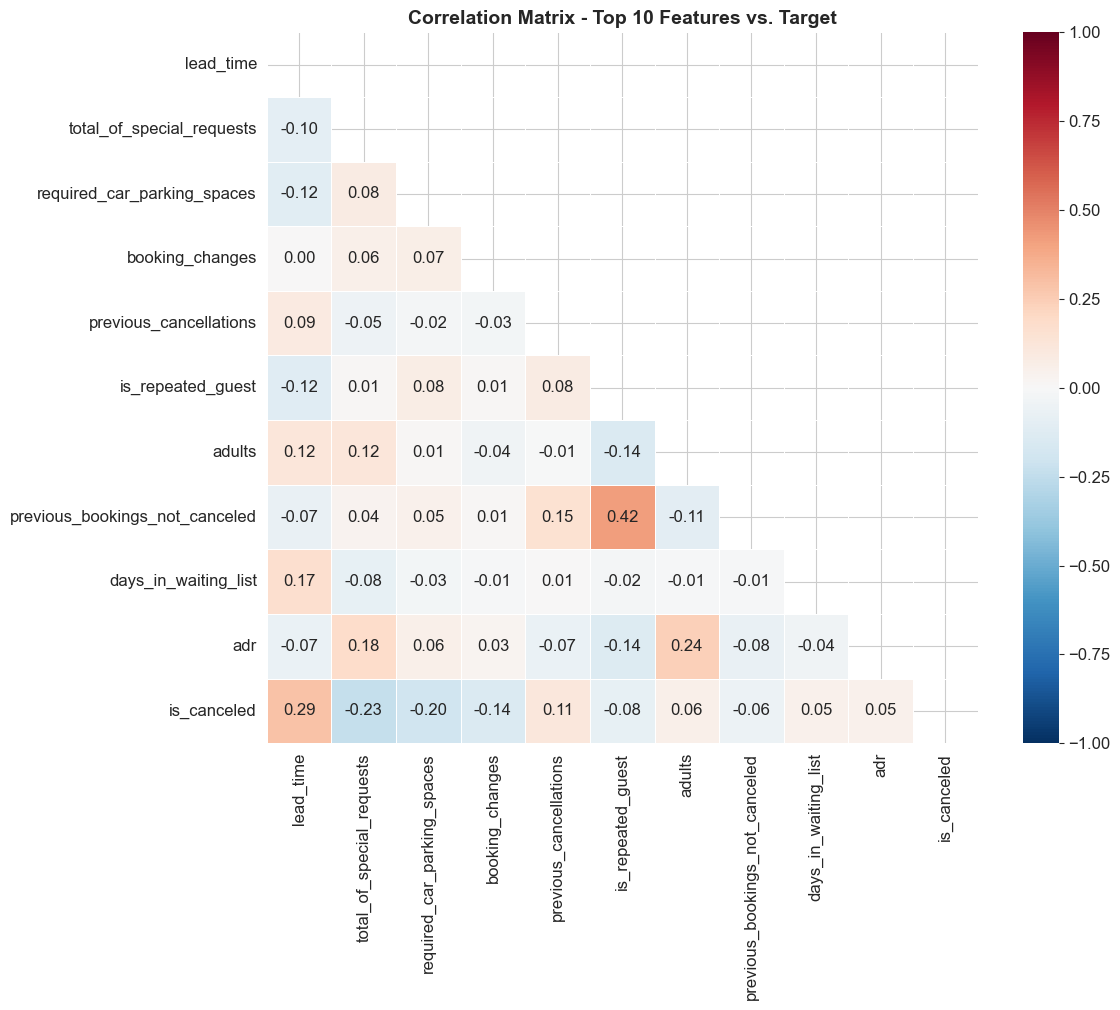

In [20]:
# Correlation heatmap - top features
top_features = correlations.head(10).index.tolist()
top_features.append('is_canceled')

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Top 10 Features vs. Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

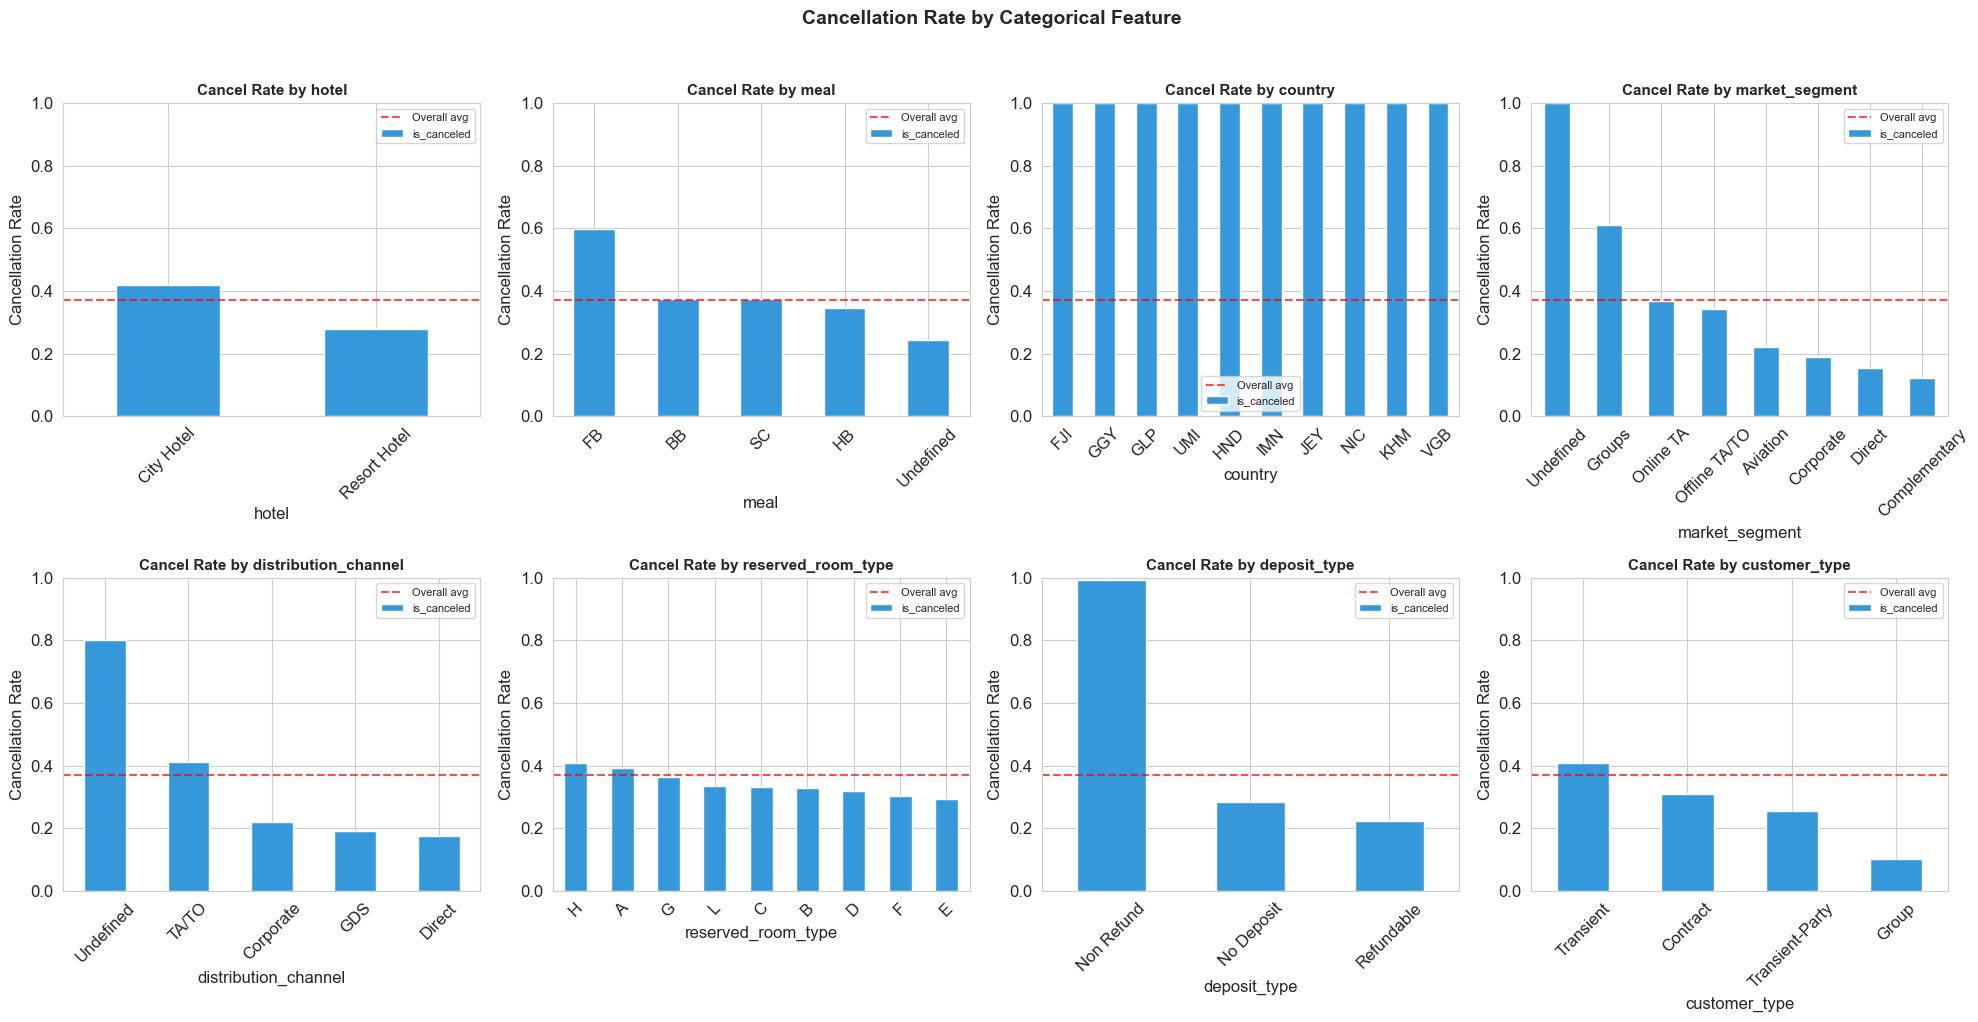

In [21]:
# --- CATEGORICAL FEATURES: Cancellation rate by category ---
categorical_cols = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
                    'reserved_room_type', 'deposit_type', 'customer_type']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
        if len(cancel_rate) > 10:
            cancel_rate = cancel_rate.head(10)

        cancel_rate.plot(kind='bar', ax=axes[i], color='#3498db', edgecolor='white')
        axes[i].set_title(f'Cancel Rate by {col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Cancellation Rate')
        axes[i].set_ylim(0, 1)
        axes[i].axhline(y=df['is_canceled'].mean(), color='red', linestyle='--',
                         alpha=0.7, label='Overall avg')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(fontsize=8)

plt.suptitle('Cancellation Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# --- STATISTICAL TESTS ---
from scipy.stats import pointbiserialr, chi2_contingency

print("Statistical Tests - Feature Importance")
print("=" * 70)

# Point-biserial for numerical features
print("\nNumerical Features (Point-Biserial Correlation):")
print("-" * 60)
results_num = []
for col in numerical_cols:
    if df[col].nunique() > 1:
        corr, pval = pointbiserialr(df['is_canceled'], df[col])
        results_num.append((col, abs(corr), pval))

results_num.sort(key=lambda x: x[1], reverse=True)
for col, corr, pval in results_num[:15]:
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {col:<40} |r| = {corr:.4f}  p = {pval:.2e}  {sig}")

Statistical Tests - Feature Importance

Numerical Features (Point-Biserial Correlation):
------------------------------------------------------------
  lead_time                                |r| = 0.2929  p = 0.00e+00  ***
  total_of_special_requests                |r| = 0.2349  p = 0.00e+00  ***
  required_car_parking_spaces              |r| = 0.1957  p = 0.00e+00  ***
  booking_changes                          |r| = 0.1448  p = 0.00e+00  ***
  previous_cancellations                   |r| = 0.1101  p = 2.49e-318  ***
  is_repeated_guest                        |r| = 0.0837  p = 2.32e-184  ***
  adults                                   |r| = 0.0582  p = 6.55e-90  ***
  previous_bookings_not_canceled           |r| = 0.0574  p = 2.01e-87  ***
  days_in_waiting_list                     |r| = 0.0543  p = 1.55e-78  ***
  adr                                      |r| = 0.0486  p = 3.00e-63  ***
  babies                                   |r| = 0.0326  p = 2.37e-29  ***
  stays_in_week_nights 

In [23]:
# Cramer's V for categorical features
def cramers_v(x, y):
    """Compute Cramer's V - strength of association between two categorical variables."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = len(x)
    min_dim = min(contingency.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

print("Categorical Features (Cramer's V with is_canceled):")
print("-" * 60)

results_cat = []
for col in categorical_cols:
    if col in df.columns:
        v = cramers_v(df[col], df['is_canceled'])
        results_cat.append((col, v))

results_cat.sort(key=lambda x: x[1], reverse=True)
for col, v in results_cat:
    strength = 'Strong' if v > 0.25 else 'Moderate' if v > 0.10 else 'Weak'
    print(f"  {col:<35} V = {v:.4f}  ({strength})")

Categorical Features (Cramer's V with is_canceled):
------------------------------------------------------------
  deposit_type                        V = 0.4815  (Strong)
  country                             V = 0.3620  (Strong)
  market_segment                      V = 0.2670  (Strong)
  distribution_channel                V = 0.1772  (Moderate)
  hotel                               V = 0.1371  (Moderate)
  customer_type                       V = 0.1366  (Moderate)
  reserved_room_type                  V = 0.0728  (Weak)
  meal                                V = 0.0506  (Weak)


### 6.1 Key Findings from Correlation Study

**Top numerical predictors of cancellation:**
1. **`lead_time`** - longer lead = higher cancel risk (strongest signal)
2. **`total_of_special_requests`** - more requests = lower cancel risk (guest is invested)
3. **`previous_cancellations`** - direct behavioural signal from history
4. **`adr`** - price sensitivity indicator
5. **`is_repeated_guest`** - returning guests cancel less

**Top categorical predictors:**
1. **`deposit_type`** - strongest categorical signal (counter-intuitively, non-refundable correlates with higher cancellation)
2. **`market_segment`** - Online TA vs Direct vs Corporate show very different patterns
3. **`customer_type`** - Transient vs Group vs Contract behaviour differs

**Weak-signal features** (candidates for removal to reduce noise):
- `babies`, `days_in_waiting_list`, `required_car_parking_spaces` - near-zero correlation

---
## 7. Feature Engineering

New features that capture domain knowledge the raw data does not express. Good feature engineering is often the difference between 0.82 AUC and 0.88 AUC.

### 7.1 Stay & Guest Features

In [24]:
# --- STAY DURATION ---
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_zero_night'] = (df['total_stay_nights'] == 0).astype(int)
df['weekend_ratio'] = np.where(
    df['total_stay_nights'] > 0,
    df['stays_in_weekend_nights'] / df['total_stay_nights'],
    0
)

print("Stay features created:")
print(f"  total_stay_nights - range: {df['total_stay_nights'].min()} to {df['total_stay_nights'].max()}")
print(f"  is_zero_night - count: {df['is_zero_night'].sum()}")
print(f"  weekend_ratio - mean: {df['weekend_ratio'].mean():.2f}")

Stay features created:
  total_stay_nights - range: 0 to 69
  is_zero_night - count: 645
  weekend_ratio - mean: 0.25


In [25]:
# --- TOTAL GUESTS ---
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['has_children'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

print(f"total_guests - mean: {df['total_guests'].mean():.1f}, max: {df['total_guests'].max()}")
print(f"has_children - {df['has_children'].mean()*100:.1f}% of bookings")

total_guests - mean: 2.0, max: 55
has_children - 7.8% of bookings


### 7.2 Lead Time Features

In [26]:
# --- LEAD TIME BUCKETS & TRANSFORMS ---
df['lead_time_bucket'] = pd.cut(
    df['lead_time'],
    bins=[0, 7, 30, 90, 180, 365, float('inf')],
    labels=['<1 week', '1-4 weeks', '1-3 months', '3-6 months', '6-12 months', '12+ months'],
    right=True, include_lowest=True
)

# Log transform (reduces skew)
df['lead_time_log'] = np.log1p(df['lead_time'])

# Last-minute flag (booked within 3 days)
df['is_last_minute'] = (df['lead_time'] <= 3).astype(int)

print("Lead time bucket distribution:")
print(df['lead_time_bucket'].value_counts().sort_index())
print(f"\nLast-minute bookings: {df['is_last_minute'].mean()*100:.1f}%")

Lead time bucket distribution:
lead_time_bucket
<1 week        19635
1-4 weeks      18945
1-3 months     29529
3-6 months     26420
6-12 months    21533
12+ months      3147
Name: count, dtype: int64

Last-minute bookings: 11.4%


### 7.3 Calendar & Seasonal Features

In [27]:
# --- ARRIVAL DATE FEATURES ---
df['arrival_day_of_week'] = df['arrival_date'].dt.dayofweek  # 0=Mon, 6=Sun
df['arrival_week_of_year'] = df['arrival_date'].dt.isocalendar().week.astype(int)
df['is_weekend_arrival'] = (df['arrival_day_of_week'] >= 5).astype(int)

# Season mapping
month_to_season = {
    'January': 'Winter', 'February': 'Winter', 'March': 'Spring',
    'April': 'Spring', 'May': 'Spring', 'June': 'Summer',
    'July': 'Summer', 'August': 'Summer', 'September': 'Autumn',
    'October': 'Autumn', 'November': 'Autumn', 'December': 'Winter'
}
df['season'] = df['arrival_date_month'].map(month_to_season)

# Days until weekend from arrival
df['days_until_weekend'] = (5 - df['arrival_day_of_week']).clip(lower=0)

print("Calendar features:")
print(f"  Weekend arrivals: {df['is_weekend_arrival'].mean()*100:.1f}%")
print(f"  Season distribution:")
print(df['season'].value_counts().to_string())

Calendar features:
  Weekend arrivals: 27.0%
  Season distribution:
season
Summer    37434
Spring    32625
Autumn    28418
Winter    20732


### 7.4 Booking Behaviour Features

In [28]:
# --- CUSTOMER HISTORY SIGNALS ---
df['total_previous_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']

# Previous cancellation ratio
df['prev_cancel_ratio'] = np.where(
    df['total_previous_bookings'] > 0,
    df['previous_cancellations'] / df['total_previous_bookings'],
    -1  # -1 signals "no history" - a distinct category
)

# First-time guest flag
df['is_first_time'] = (df['total_previous_bookings'] == 0).astype(int)

print("Booking history features:")
print(f"  First-time guests: {df['is_first_time'].mean()*100:.1f}%")
print(f"  Guests with prior cancellations: {(df['previous_cancellations'] > 0).mean()*100:.1f}%")

Booking history features:
  First-time guests: 92.1%
  Guests with prior cancellations: 5.4%


In [29]:
# --- ENGAGEMENT SIGNALS ---
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)
df['has_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)

print(f"Guests with special requests: {df['has_special_requests'].mean()*100:.1f}%")
print(f"Guests requesting parking: {df['has_parking'].mean()*100:.1f}%")

Guests with special requests: 41.1%
Guests requesting parking: 6.2%


### 7.5 Price & Revenue Features

In [30]:
# --- ADR (PRICE) FEATURES ---
df['adr_per_guest'] = np.where(
    df['total_guests'] > 0, df['adr'] / df['total_guests'], df['adr']
)
df['adr_per_night'] = np.where(
    df['total_stay_nights'] > 0, df['adr'] / df['total_stay_nights'], df['adr']
)
df['total_revenue'] = df['adr'] * np.maximum(df['total_stay_nights'], 1)

# Is above-average price for this hotel type?
adr_means = df.groupby('hotel')['adr'].transform('mean')
df['adr_above_avg'] = (df['adr'] > adr_means).astype(int)

print("Price features:")
print(f"  adr_per_guest - mean: EUR {df['adr_per_guest'].mean():.1f}")
print(f"  total_revenue - mean: EUR {df['total_revenue'].mean():.0f}")
print(f"  Above-average ADR: {df['adr_above_avg'].mean()*100:.1f}%")

Price features:
  adr_per_guest - mean: EUR 54.9
  total_revenue - mean: EUR 358
  Above-average ADR: 41.3%


### 7.6 Market Segment Features

In [31]:
# --- SEGMENT-LEVEL STATISTICS ---
df['segment_cancel_rate'] = df.groupby('market_segment')['is_canceled'].transform('mean')

# Channel flags
df['is_ota'] = (df['market_segment'] == 'Online TA').astype(int)
df['is_direct'] = (df['market_segment'] == 'Direct').astype(int)
df['is_corporate'] = (df['market_segment'] == 'Corporate').astype(int)

print("Segment cancel rates:")
print(df.groupby('market_segment')['is_canceled'].agg(['mean', 'count']).sort_values('mean', ascending=False).round(3))

Segment cancel rates:
                 mean  count
market_segment              
Undefined       1.000      2
Groups          0.611  19790
Online TA       0.368  56408
Offline TA/TO   0.343  24182
Aviation        0.221    235
Corporate       0.188   5282
Direct          0.154  12582
Complementary   0.122    728


### 7.7 Deposit & Financial Commitment Features

In [32]:
# --- DEPOSIT FEATURES ---
df['has_deposit'] = (df['deposit_type'] != 'No Deposit').astype(int)

print("Cancellation rate by deposit type:")
print(df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).round(3))
print(f"\nHas deposit: {df['has_deposit'].mean()*100:.1f}%")

Cancellation rate by deposit type:
               mean   count
deposit_type               
No Deposit    0.284  104460
Non Refund    0.994   14587
Refundable    0.222     162

Has deposit: 12.4%


---
## 8. Feature Engineering Validation

Verify new features are predictive and check final dataset quality.

In [33]:
# --- CORRELATION OF ENGINEERED FEATURES WITH TARGET ---
engineered_features = [
    'total_stay_nights', 'is_zero_night', 'weekend_ratio',
    'total_guests', 'has_children',
    'lead_time_log', 'is_last_minute',
    'is_weekend_arrival', 'days_until_weekend',
    'total_previous_bookings', 'prev_cancel_ratio', 'is_first_time',
    'has_special_requests', 'has_parking',
    'adr_per_guest', 'adr_per_night', 'total_revenue', 'adr_above_avg',
    'segment_cancel_rate', 'is_ota', 'is_direct', 'is_corporate',
    'has_deposit'
]

new_corr = df[engineered_features].corrwith(df['is_canceled']).sort_values(key=abs, ascending=False)

print("Engineered Features - Correlation with is_canceled:")
print("=" * 60)
for feat, corr in new_corr.items():
    bar_len = int(abs(corr) * 50)
    bar = '#' * bar_len
    direction = '+' if corr > 0 else '-'
    print(f"  {feat:<35} {direction}{abs(corr):.4f}  {bar}")

Engineered Features - Correlation with is_canceled:
  has_deposit                         +0.4780  #######################
  lead_time_log                       +0.3201  ################
  segment_cancel_rate                 +0.2670  #############
  has_special_requests                -0.2649  #############
  prev_cancel_ratio                   +0.2317  ###########
  is_last_minute                      -0.2136  ##########
  has_parking                         -0.1976  #########
  is_first_time                       -0.1612  ########
  is_direct                           -0.1544  #######
  is_corporate                        -0.0816  ####
  is_zero_night                       -0.0512  ##
  total_revenue                       +0.0462  ##
  total_guests                        +0.0448  ##
  adr_per_night                       -0.0364  #
  days_until_weekend                  -0.0308  #
  weekend_ratio                       -0.0237  #
  adr_per_guest                       +0.0196  
  total_s

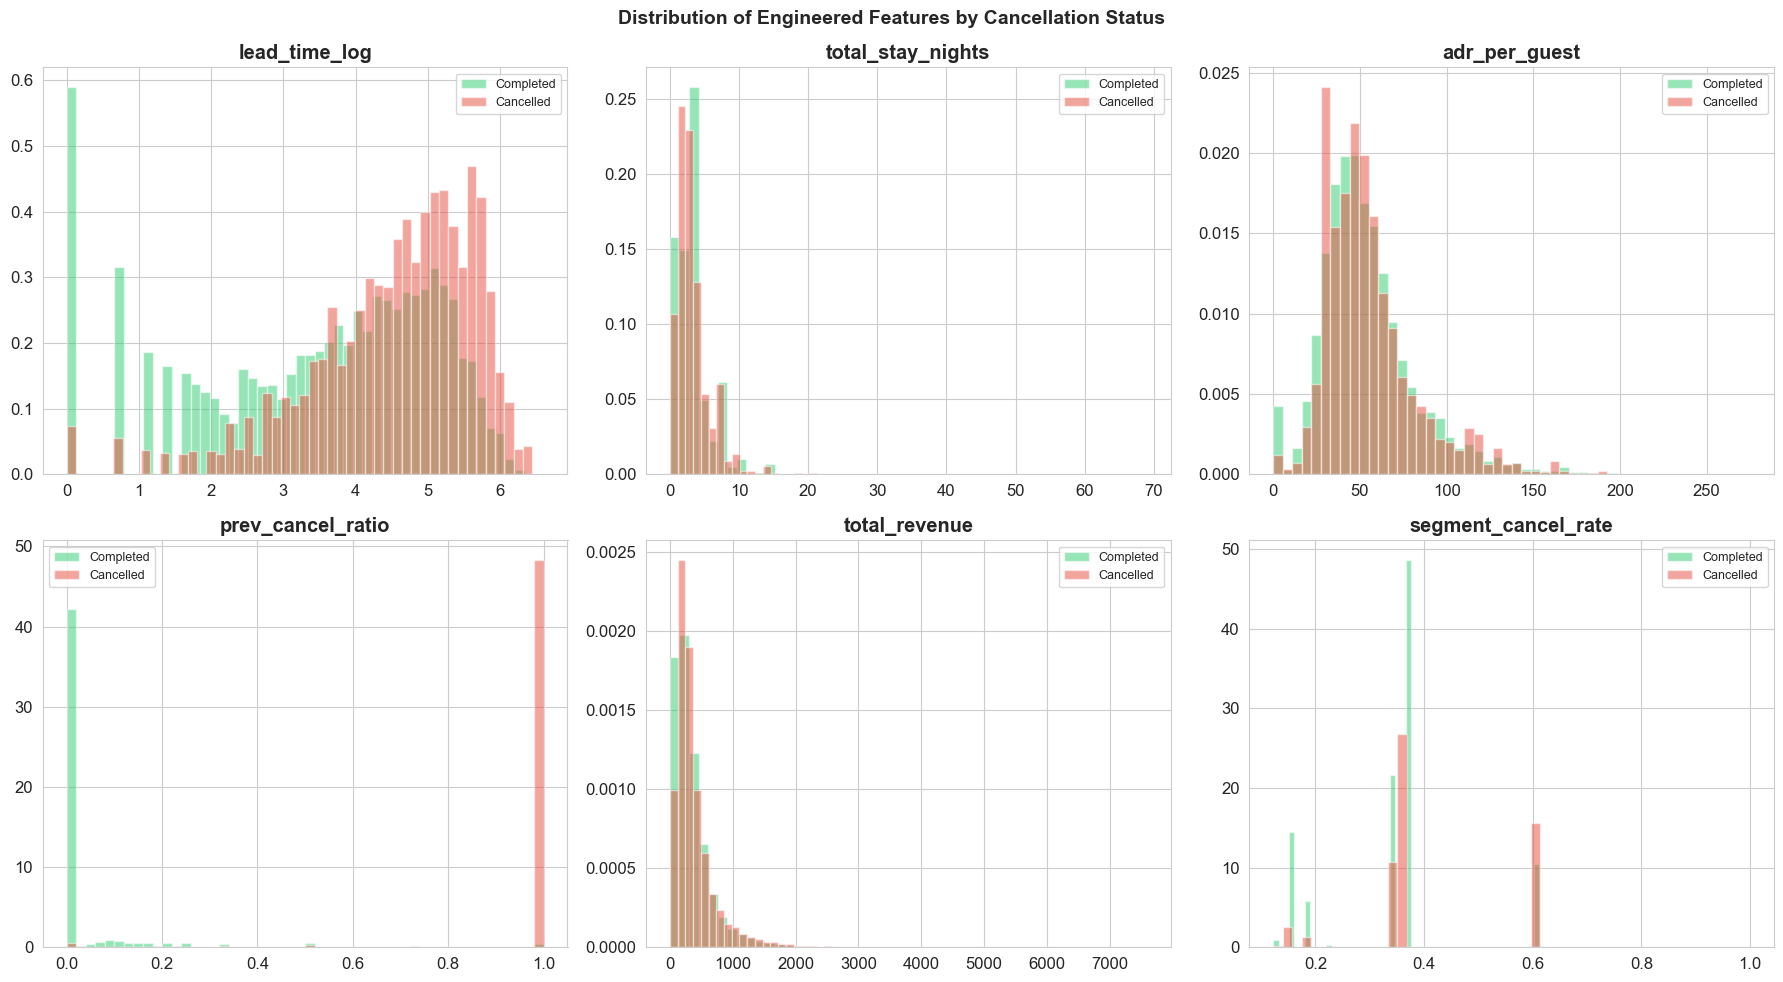

In [34]:
# Visualise top engineered features vs. cancellation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_features = ['lead_time_log', 'total_stay_nights', 'adr_per_guest',
                 'prev_cancel_ratio', 'total_revenue', 'segment_cancel_rate']

for i, feat in enumerate(plot_features):
    ax = axes[i // 3][i % 3]
    data = df[df[feat] != -1] if feat == 'prev_cancel_ratio' else df

    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = data[data['is_canceled'] == label][feat]
        ax.hist(subset, bins=50, alpha=0.5, color=color, density=True,
                label='Completed' if label == 0 else 'Cancelled')

    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Engineered Features by Cancellation Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Final Dataset Summary

In [35]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Rows:                      {df.shape[0]:,}")
print(f"Original features:         32")
print(f"Total columns now:         {df.shape[1]}")
print(f"Engineered features added: {len(engineered_features)}")
print(f"Leakage features removed:  2 (reservation_status, reservation_status_date)")
print(f"Missing values:            {df.isnull().sum().sum()}")
cancel_rate = df['is_canceled'].mean()
print(f"Target balance:            {cancel_rate*100:.1f}% cancelled / {(1-cancel_rate)*100:.1f}% completed")
print()
print("Column types:")
print(df.dtypes.value_counts().to_string())

FINAL DATASET SUMMARY
Rows:                      119,209
Original features:         32
Total columns now:         58
Engineered features added: 23
Leakage features removed:  2 (reservation_status, reservation_status_date)
Missing values:            0
Target balance:            37.1% cancelled / 62.9% completed

Column types:
int64             33
object            13
float64            8
int32              2
datetime64[ns]     1
category           1


In [36]:
# List all columns in the final dataset
print("All columns in final dataset:")
print("-" * 65)
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    nunique = df[col].nunique()
    print(f"  {i:2d}. {col:<40} {dtype:<15} ({nunique:,} unique)")

All columns in final dataset:
-----------------------------------------------------------------
   1. hotel                                    object          (2 unique)
   2. is_canceled                              int64           (2 unique)
   3. lead_time                                int64           (479 unique)
   4. arrival_date_year                        int64           (3 unique)
   5. arrival_date_month                       object          (12 unique)
   6. arrival_date_week_number                 int64           (53 unique)
   7. arrival_date_day_of_month                int64           (31 unique)
   8. stays_in_weekend_nights                  int64           (17 unique)
   9. stays_in_week_nights                     int64           (33 unique)
  10. adults                                   int64           (14 unique)
  11. children                                 int64           (5 unique)
  12. babies                                   int64           (5 unique)
  13. me

In [37]:
# Save the cleaned & engineered dataset
output_path = 'hotel_bookings_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to '{output_path}'")
print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")

Saved cleaned dataset to 'hotel_bookings_cleaned.csv'
Shape: 119,209 x 58


---
## 10. Next Steps

With the cleaned and engineered dataset ready, the next phases of the NoShowShield pipeline are:

1. **Train/test split** - temporal: train on 2015-2016, test on 2017
2. **Baseline model** - logistic regression to establish a performance floor
3. **XGBoost training** - gradient-boosted classifier with hyperparameter tuning
4. **SHAP integration** - global and local explainability
5. **Poisson-Binomial optimisation** - convert probabilities into overbooking recommendations
6. **FastAPI + Streamlit** - deploy as a usable product

---
*NoShowShield | Bezawit Zerayacob | March 2026*